# LAB03 — Ensambles, reducción dimensional y Green AI

## Protocolo congelado

Este laboratorio amplía el problema desarrollado en LAB02 utilizando el mismo dataset, target, tratamiento de duplicados, variables predictoras y partición de entrenamiento y prueba.

- **Dataset:** Online Shoppers Purchasing Intention
- **Target:** `Revenue`
- **Tipo de problema:** clasificación binaria
- **Métrica principal:** F1-macro
- **Clase prioritaria:** `Revenue=True`
- **Partición:** 80 % entrenamiento / 20 % prueba
- **Estratificación:** sí
- **Random state:** 42
- **Registros después de eliminar duplicados exactos:** 12,205
- **Entrenamiento:** 9,764 observaciones
- **Prueba:** 2,441 observaciones

La partición no será modificada para favorecer ningún modelo. Todas las configuraciones utilizarán el mismo protocolo de preprocesamiento y los mismos conjuntos de entrenamiento y prueba.

El conjunto de prueba se mantendrá sin modificaciones durante los experimentos.

In [2]:
from pathlib import Path
from time import perf_counter

import joblib
import numpy as np
import pandas as pd

In [3]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

data_path = (
    project_root
    / "data"
    / "raw"
    / "online_shoppers_intention.csv"
)

df = pd.read_csv(data_path)

# Mismo tratamiento aplicado en LAB02
df_clean = df.drop_duplicates().copy()

print("Dataset original:", df.shape)
print("Dataset después de duplicados:", df_clean.shape)

Dataset original: (12330, 18)
Dataset después de duplicados: (12205, 18)


## Reconstrucción del protocolo de LAB02

Se utilizan las mismas variables predictoras, el mismo target y la misma partición estratificada definida en LAB02.

La reproducibilidad se verifica mediante las dimensiones y los conteos de clases esperados en entrenamiento y prueba.

In [4]:
from sklearn.model_selection import train_test_split


numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay",
]

categorical_features = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend",
]

target = "Revenue"

X = df_clean.drop(columns=[target]).copy()
y = df_clean[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

X_train: (9764, 17)
X_test: (2441, 17)

y_train:
Revenue
False    8238
True     1526
Name: count, dtype: int64

y_test:
Revenue
False    2059
True      382
Name: count, dtype: int64


In [5]:
assert X_train.shape == (9764, 17)
assert X_test.shape == (2441, 17)

assert y_train.value_counts().to_dict() == {
    False: 8238,
    True: 1526,
}

assert y_test.value_counts().to_dict() == {
    False: 2059,
    True: 382,
}

print("\nProtocolo LAB02 reproducido correctamente.")


Protocolo LAB02 reproducido correctamente.


## Preprocesamiento congelado

Se conserva el mismo esquema utilizado en LAB02. Las variables numéricas utilizan imputación por mediana y estandarización, mientras que las categóricas utilizan imputación por moda y One-Hot Encoding.

El preprocesamiento permanecerá idéntico para todos los modelos comparados.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Preprocesador LAB02 reconstruido correctamente.")

Preprocesador LAB02 reconstruido correctamente.


## Catálogo de modelos

Se compararán seis configuraciones bajo exactamente el mismo conjunto de entrenamiento, prueba y preprocesamiento.

El catálogo incluye regresión logística como referencia adicional, dos configuraciones de SVM, dos configuraciones de Random Forest y un modelo de boosting.

Todos los modelos utilizarán el mismo protocolo definido previamente para que las diferencias observadas sean atribuibles al algoritmo y no a cambios en los datos o en la partición.

In [7]:
from sklearn.base import clone
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


models = {
    "logistic": Pipeline(
        [
            ("prep", clone(preprocessor)),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                ),
            ),
        ]
    ),

    "svm_c1": Pipeline(
        [
            ("prep", clone(preprocessor)),
            (
                "model",
                SVC(
                    C=1,
                    probability=True,
                    random_state=42,
                ),
            ),
        ]
    ),

    "svm_c10": Pipeline(
        [
            ("prep", clone(preprocessor)),
            (
                "model",
                SVC(
                    C=10,
                    probability=True,
                    random_state=42,
                ),
            ),
        ]
    ),

    "rf_100": Pipeline(
        [
            ("prep", clone(preprocessor)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=100,
                    max_depth=8,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),

    "rf_300": Pipeline(
        [
            ("prep", clone(preprocessor)),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    max_depth=8,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),

    "boost": Pipeline(
        [
            ("prep", clone(preprocessor)),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_depth=6,
                    random_state=42,
                ),
            ),
        ]
    ),
}

print("Número de configuraciones:", len(models))
print("Modelos:")
for name in models:
    print("-", name)

Número de configuraciones: 6
Modelos:
- logistic
- svm_c1
- svm_c10
- rf_100
- rf_300
- boost


## Medición repetida de rendimiento y costo computacional

Cada configuración será entrenada tres veces utilizando exactamente el mismo conjunto de entrenamiento.

Se registrará:

- F1-macro en el conjunto de prueba.
- Recall-macro.
- Recall de la clase prioritaria `Revenue=True`.
- Mediana del tiempo de entrenamiento de tres repeticiones.
- Tiempo de inferencia sobre el conjunto de prueba.
- Tamaño del modelo serializado.

Los tiempos representan el comportamiento observado en el entorno de ejecución utilizado y no deben interpretarse como una medición directa de consumo energético.

In [8]:
from sklearn.metrics import f1_score, recall_score


models_dir = project_root / "reports" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

rows = []

for name, base_model in models.items():
    print(f"\nModelo: {name}")

    fit_times = []
    fitted_model = None

    for repetition in range(1, 4):
        model = clone(base_model)

        start = perf_counter()
        model.fit(X_train, y_train)
        fit_time = perf_counter() - start

        fit_times.append(fit_time)
        fitted_model = model

        print(
            f"  Repetición {repetition}: "
            f"{fit_time:.4f} segundos"
        )

    start = perf_counter()
    pred = fitted_model.predict(X_test)
    predict_ms = (perf_counter() - start) * 1000

    model_path = models_dir / f"{name}.joblib"
    joblib.dump(fitted_model, model_path)

    rows.append(
        {
            "model": name,
            "f1_macro": f1_score(
                y_test,
                pred,
                average="macro",
            ),
            "recall_macro": recall_score(
                y_test,
                pred,
                average="macro",
            ),
            "recall_revenue_true": recall_score(
                y_test,
                pred,
                pos_label=True,
            ),
            "fit_median_s": np.median(fit_times),
            "predict_ms": predict_ms,
            "size_kb": model_path.stat().st_size / 1024,
        }
    )

results = pd.DataFrame(rows)

results = results.sort_values(
    "f1_macro",
    ascending=False,
).reset_index(drop=True)

display(results.round(4))


Modelo: logistic
  Repetición 1: 0.0941 segundos
  Repetición 2: 0.0837 segundos
  Repetición 3: 0.0728 segundos

Modelo: svm_c1


c:\Users\Gladys\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Repetición 1: 6.1973 segundos


c:\Users\Gladys\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Repetición 2: 6.3972 segundos


...

c:\Users\Gladys\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Repetición 2: 7.6364 segundos


c:\Users\Gladys\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Repetición 3: 7.6617 segundos

Modelo: rf_100
  Repetición 1: 0.1533 segundos
  Repetición 2: 0.1502 segundos
  Repetición 3: 0.1529 segundos

Modelo: rf_300
  Repetición 1: 0.3743 segundos
  Repetición 2: 0.3880 segundos
  Repetición 3: 0.3912 segundos

Modelo: boost
  Repetición 1: 0.2430 segundos
  Repetición 2: 0.2701 segundos
  Repetición 3: 0.2443 segundos


,model,f1_macro,recall_macro,recall_revenue_true,fit_median_s,predict_ms,size_kb
0,boost,0.8006,0.7835,0.6126,0.2443,13.3632,333.5488
1,svm_c1,0.7740,0.7419,0.5183,6.3510,418.6143,1681.6152
2,svm_c10,0.7688,0.7463,0.5393,7.6617,429.1537,1771.8809
3,logistic,0.7347,0.6942,0.4136,0.0837,6.8037,6.7441
4,rf_100,0.7121,0.6642,0.3377,0.1529,31.8306,2065.0732
5,rf_300,0.7116,0.6640,0.3377,0.3880,53.8300,6169.6045


### Interpretación inicial de las mediciones

Las seis configuraciones fueron entrenadas tres veces bajo el mismo protocolo y se utilizó la mediana del tiempo de ajuste como medida temporal.

`boost` obtuvo el mayor F1-macro (0.8006) y el mayor recall para la clase prioritaria `Revenue=True` (0.6126), con un tiempo mediano de entrenamiento de 0.2730 segundos.

La regresión logística presentó el menor tiempo de entrenamiento (0.0800 segundos), la inferencia más rápida y el menor tamaño serializado, aunque su F1-macro fue inferior (0.7347).

El incremento de 100 a 300 árboles en Random Forest no mejoró el F1-macro y aumentó tanto el tiempo de entrenamiento como el tamaño del modelo.

En las configuraciones SVM, aumentar C de 1 a 10 incrementó ligeramente el recall de `Revenue=True`, pero redujo el F1-macro y aumentó el costo temporal.

La selección definitiva no se realizará únicamente con estas métricas, sino después de analizar la reducción dimensional y la frontera de Pareto.

## Comparación de SVM con y sin PCA

Debido a que el dataset contiene variables numéricas y categóricas, PCA se aplicará únicamente al bloque numérico.

Las variables numéricas serán imputadas, estandarizadas y reducidas mediante PCA conservando el 95 % de la varianza. Las variables categóricas mantendrán el mismo tratamiento utilizado previamente.

La comparación utilizará la configuración SVM con `C=1` para aislar el efecto de la reducción dimensional.

In [9]:
from sklearn.decomposition import PCA


numeric_transformer_pca = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "pca",
            PCA(
                n_components=0.95,
                random_state=42,
            ),
        ),
    ]
)

preprocessor_pca = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_pca, numeric_features),
        ("cat", clone(categorical_transformer), categorical_features),
    ]
)

svm_pca = Pipeline(
    steps=[
        ("prep", preprocessor_pca),
        (
            "model",
            SVC(
                C=1,
                probability=True,
                random_state=42,
            ),
        ),
    ]
)

start = perf_counter()
svm_pca.fit(X_train, y_train)
pca_fit_time = perf_counter() - start

pca_pred = svm_pca.predict(X_test)

pca_f1 = f1_score(
    y_test,
    pca_pred,
    average="macro",
)

pca_recall_true = recall_score(
    y_test,
    pca_pred,
    pos_label=True,
)

pca_step = (
    svm_pca
    .named_steps["prep"]
    .named_transformers_["num"]
    .named_steps["pca"]
)

print("Variables numéricas originales:", len(numeric_features))
print("Componentes PCA seleccionados:", pca_step.n_components_)
print("Varianza explicada acumulada:", round(pca_step.explained_variance_ratio_.sum(), 4))

print("\nSVM sin PCA - F1 macro:", round(
    results.loc[results["model"] == "svm_c1", "f1_macro"].iloc[0],
    4,
))

print("SVM con PCA - F1 macro:", round(pca_f1, 4))
print("SVM con PCA - Recall Revenue=True:", round(pca_recall_true, 4))
print("Tiempo de ajuste con PCA:", round(pca_fit_time, 4), "segundos")

c:\Users\Gladys\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Variables numéricas originales: 10
Componentes PCA seleccionados: 8
Varianza explicada acumulada: 0.9784

SVM sin PCA - F1 macro: 0.774
SVM con PCA - F1 macro: 0.7734
SVM con PCA - Recall Revenue=True: 0.5157
Tiempo de ajuste con PCA: 5.8953 segundos


### Interpretación de PCA

PCA redujo las 10 variables numéricas originales a 8 componentes, conservando aproximadamente el 97.84 % de la varianza acumulada.

La SVM sin PCA obtuvo un F1-macro de 0.7740, mientras que la versión con PCA alcanzó 0.7734. La diferencia absoluta fue de apenas 0.0006, por lo que la reducción dimensional no produjo un cambio relevante en el desempeño predictivo.

El recall de la clase prioritaria `Revenue=True` también permaneció muy próximo al modelo original. Por tanto, PCA permitió reducir parcialmente la dimensionalidad del bloque numérico sin una pérdida sustancial de rendimiento.

El tiempo de ajuste observado con PCA fue de 5.8953 segundos. Este valor se interpreta únicamente como una medición contextual y no como evidencia directa de ahorro energético.

### Varianza acumulada explicada mediante PCA

La siguiente figura muestra la proporción acumulada de varianza explicada por los componentes principales obtenidos a partir de las variables numéricas. Se utiliza como referencia el umbral del 95 % para evaluar cuántos componentes permiten conservar la mayor parte de la información original.

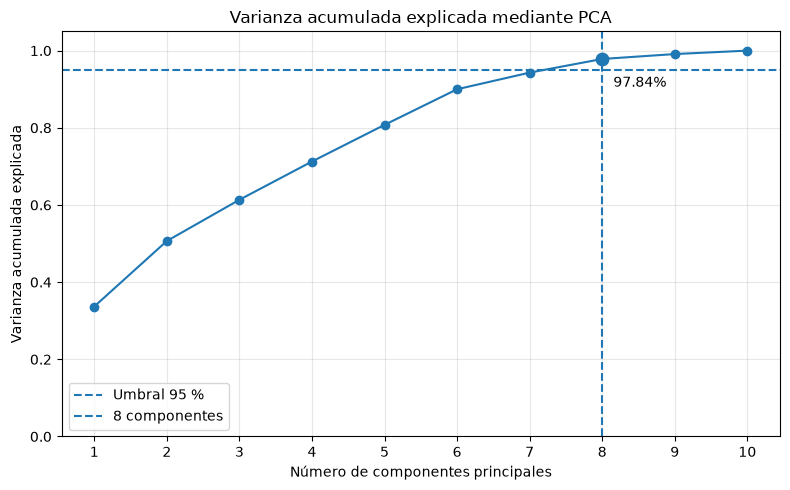

Figura guardada en:
c:\Users\Gladys\INF8239_U01\reports\pca_cumulative_variance.png

Componentes para alcanzar al menos 95 %: 8
Varianza acumulada con 8 componentes: 0.9784 (97.84%)


In [20]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------
# 1. Preparar únicamente las variables numéricas
# ---------------------------------------------------------
X_train_numeric = X_train[numeric_features].copy()

numeric_imputer = SimpleImputer(strategy="median")
numeric_scaler = StandardScaler()

X_train_numeric_imputed = numeric_imputer.fit_transform(
    X_train_numeric
)

X_train_numeric_scaled = numeric_scaler.fit_transform(
    X_train_numeric_imputed
)


# ---------------------------------------------------------
# 2. PCA con todos los componentes para estudiar la varianza
# ---------------------------------------------------------
pca_full = PCA()

pca_full.fit(X_train_numeric_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

components = np.arange(
    1,
    len(cumulative_variance) + 1
)


# ---------------------------------------------------------
# 3. Identificar cuántos componentes alcanzan al menos 95 %
# ---------------------------------------------------------
components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

variance_95 = cumulative_variance[
    components_95 - 1
]


# ---------------------------------------------------------
# 4. Crear la figura
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    components,
    cumulative_variance,
    marker="o",
)

ax.axhline(
    y=0.95,
    linestyle="--",
    label="Umbral 95 %",
)

ax.axvline(
    x=components_95,
    linestyle="--",
    label=f"{components_95} componentes",
)

ax.scatter(
    components_95,
    variance_95,
    s=80,
)

ax.annotate(
    f"{variance_95:.2%}",
    (
        components_95,
        variance_95,
    ),
    xytext=(8, -20),
    textcoords="offset points",
)

ax.set_title(
    "Varianza acumulada explicada mediante PCA"
)

ax.set_xlabel(
    "Número de componentes principales"
)

ax.set_ylabel(
    "Varianza acumulada explicada"
)

ax.set_xticks(components)

ax.set_ylim(0, 1.05)

ax.grid(
    alpha=0.3
)

ax.legend()

plt.tight_layout()


# ---------------------------------------------------------
# 5. Guardar figura
# ---------------------------------------------------------
pca_figure_path = (
    project_root
    / "reports"
    / "pca_cumulative_variance.png"
)

plt.savefig(
    pca_figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada en:")
print(pca_figure_path)

print(
    f"\nComponentes para alcanzar al menos 95 %: "
    f"{components_95}"
)

print(
    f"Varianza acumulada con {components_95} componentes: "
    f"{variance_95:.4f} "
    f"({variance_95:.2%})"
)

## Visualización t-SNE

Se utilizará t-SNE sobre una muestra de hasta 1,000 observaciones y exclusivamente sobre las variables numéricas estandarizadas.

Se generarán dos representaciones manteniendo los mismos datos y parámetros, pero utilizando semillas diferentes (`42` y `7`). El objetivo es evaluar qué patrones visuales permanecen y cuáles dependen de la inicialización.

La separación visual observada en t-SNE no se interpretará como evidencia de causalidad ni como validación independiente del desempeño de los clasificadores.

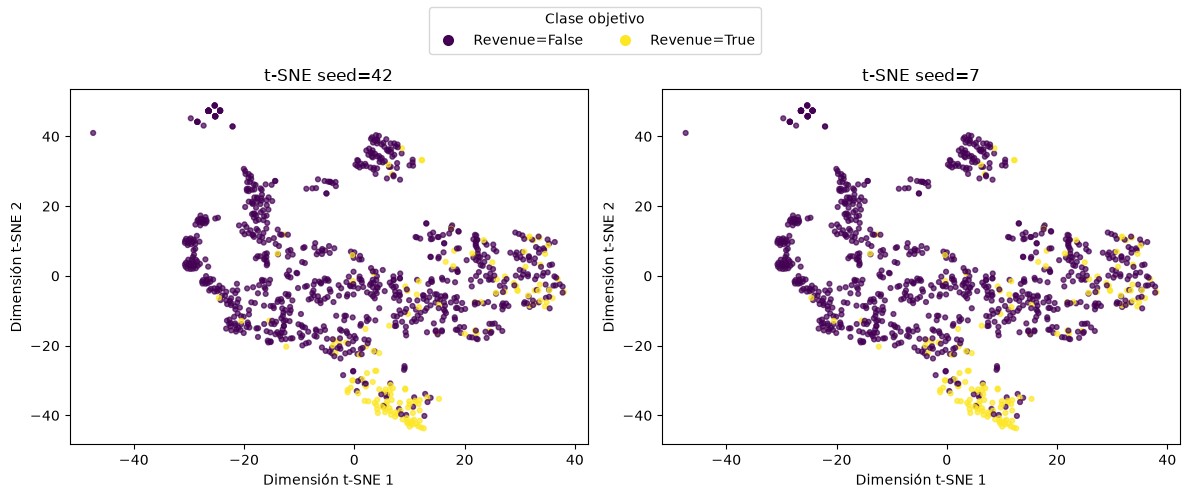

Figura guardada en:
c:\Users\Gladys\INF8239_U01\reports\tsne_two_seeds.png


In [21]:
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ---------------------------------------------------------
# 1. Preparar muestra numérica
# ---------------------------------------------------------
X_num = X[numeric_features].copy()

sample = X_num.sample(
    n=min(1000, len(X_num)),
    random_state=42,
)

y_sample = y.loc[sample.index]

scaled_sample = StandardScaler().fit_transform(sample)


# ---------------------------------------------------------
# 2. Codificar Revenue para mantener colores consistentes
# ---------------------------------------------------------
# False = 0
# True = 1
class_codes = y_sample.astype(int).to_numpy()

cmap = plt.get_cmap("viridis")


# ---------------------------------------------------------
# 3. Crear dos visualizaciones t-SNE
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

for ax, seed in zip(axes, [42, 7]):

    embedding = TSNE(
        n_components=2,
        perplexity=30,
        random_state=seed,
        init="pca",
        learning_rate="auto",
    ).fit_transform(scaled_sample)

    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=class_codes,
        s=12,
        cmap=cmap,
        vmin=0,
        vmax=1,
        alpha=0.7,
    )

    ax.set_title(f"t-SNE seed={seed}")
    ax.set_xlabel("Dimensión t-SNE 1")
    ax.set_ylabel("Dimensión t-SNE 2")


# ---------------------------------------------------------
# 4. Crear leyenda común
# ---------------------------------------------------------
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=cmap(0.0),
        markeredgecolor="none",
        markersize=8,
        label="Revenue=False",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=cmap(1.0),
        markeredgecolor="none",
        markersize=8,
        label="Revenue=True",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    title="Clase objetivo",
)


# ---------------------------------------------------------
# 5. Guardar figura
# ---------------------------------------------------------
reports_dir = project_root / "reports"
reports_dir.mkdir(exist_ok=True)

tsne_path = reports_dir / "tsne_two_seeds.png"

plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)

plt.savefig(
    tsne_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print("Figura guardada en:")
print(tsne_path)

### Interpretación de t-SNE

Las representaciones obtenidas con semillas 42 y 7 muestran una estructura global similar, lo que indica cierta estabilidad visual ante el cambio de inicialización.

En ambos mapas se observa una concentración de sesiones con `Revenue=True` en algunas regiones, especialmente en la zona inferior de la representación. Sin embargo, también existe una mezcla considerable entre las clases, por lo que no puede afirmarse que las variables numéricas separen completamente las sesiones con y sin compra.

Los cambios menores en la posición y forma de algunos grupos son esperables debido a la naturaleza estocástica de t-SNE. Los ejes y las distancias globales no poseen una interpretación directa, y la separación visual no constituye por sí sola evidencia de causalidad ni valida el desempeño de un clasificador.

## Sensibilidad de t-SNE a la perplexity

Para evaluar la estabilidad de la representación se compararán valores de `perplexity` de 5, 15, 30 y 50, manteniendo constantes la muestra, el preprocesamiento y la semilla aleatoria.

El objetivo no es seleccionar visualmente el valor que produzca grupos más atractivos, sino comprobar qué patrones permanecen relativamente estables ante cambios en la escala de vecindad.

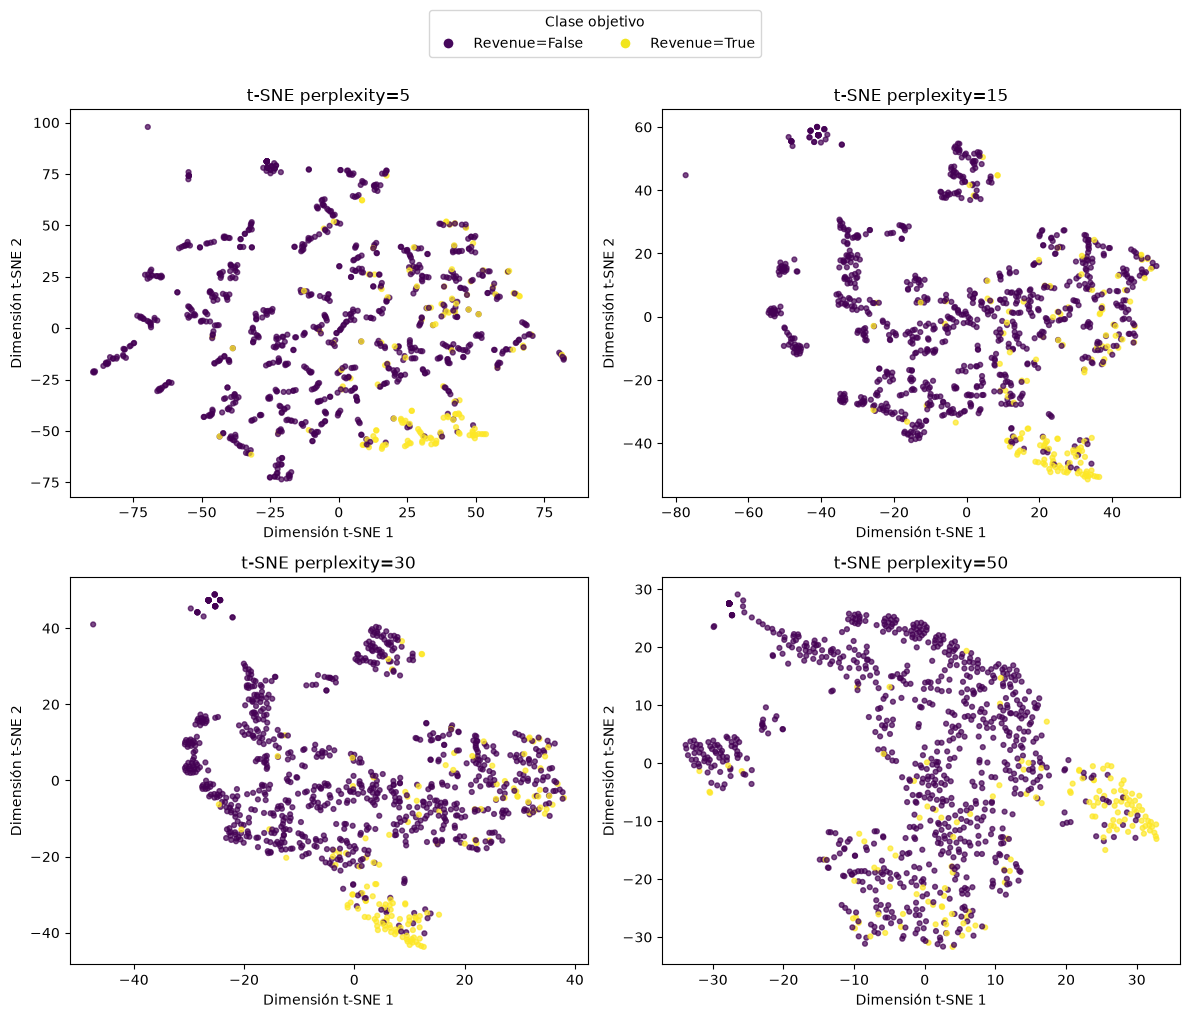

Figura guardada en:
c:\Users\Gladys\INF8239_U01\reports\tsne_perplexity_comparison.png


In [24]:
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

perplexities = [5, 15, 30, 50]

# Codificación del target para mantener colores consistentes
y_codes = pd.Categorical(y_sample, categories=[False, True]).codes

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10),
)

for ax, perplexity in zip(axes.ravel(), perplexities):
    embedding = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=42,
        init="pca",
        learning_rate="auto",
    ).fit_transform(scaled_sample)

    ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y_codes,
        s=12,
        cmap="viridis",
        alpha=0.7,
    )

    ax.set_title(f"t-SNE perplexity={perplexity}")
    ax.set_xlabel("Dimensión t-SNE 1")
    ax.set_ylabel("Dimensión t-SNE 2")

# Crear leyenda manual usando los colores extremos de viridis
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Revenue=False",
        markerfacecolor=plt.cm.viridis(0.02),
        markersize=8,
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Revenue=True",
        markerfacecolor=plt.cm.viridis(0.98),
        markersize=8,
    ),
]

fig.legend(
    handles=legend_elements,
    title="Clase objetivo",
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02),
)

perplexity_path = reports_dir / "tsne_perplexity_comparison.png"

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    perplexity_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Figura guardada en:")
print(perplexity_path)

### Sensibilidad de t-SNE a la perplexity

La comparación de `perplexity` = 5, 15, 30 y 50 muestra que la geometría de la representación cambia de manera importante según la escala de vecindad utilizada.

Con `perplexity=5` se observan numerosos grupos pequeños y una estructura más fragmentada, reflejando un mayor énfasis en relaciones locales. Al aumentar la perplexity a 15 y 30, la representación adquiere una estructura más continua y ambos valores muestran patrones generales relativamente similares. Con `perplexity=50`, varios grupos locales se integran en estructuras más amplias.

A pesar de estas variaciones, se mantiene en las diferentes representaciones una mayor concentración de observaciones `Revenue=True` en ciertas regiones, mientras que gran parte de ambas clases permanece mezclada.

Por tanto, algunos patrones locales parecen relativamente estables, pero la forma, orientación y distancia entre grupos dependen del parámetro utilizado. No se interpretan los grupos t-SNE como clases reales ni las distancias entre regiones como medidas directas de similitud.

## Frontera de Pareto

La frontera de Pareto permitirá identificar configuraciones que no sean superadas simultáneamente en desempeño predictivo y costo temporal.

Se utilizará F1-macro como medida de desempeño y la mediana del tiempo de entrenamiento como medida de costo computacional.

In [14]:
import sys
from pathlib import Path


current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print("Raíz del proyecto:", project_root)
print("Ruta src disponible:", src_path)

Raíz del proyecto: c:\Users\Gladys\INF8239_U01
Ruta src disponible: c:\Users\Gladys\INF8239_U01\src


In [15]:
from inf8239_u01.green import pareto_flags

print("Función pareto_flags importada correctamente.")

Función pareto_flags importada correctamente.


In [16]:

results["is_pareto"] = pareto_flags(
    results,
    score="f1_macro",
    cost="fit_median_s",
)

green_results_path = (
    project_root
    / "reports"
    / "green_ai_results.csv"
)

results.to_csv(
    green_results_path,
    index=False,
)

pareto_view = results.sort_values(
    ["is_pareto", "f1_macro"],
    ascending=[False, False],
)

display(pareto_view.round(4))

print("\nResultados guardados en:")
print(green_results_path)

,model,f1_macro,recall_macro,recall_revenue_true,fit_median_s,predict_ms,size_kb,is_pareto
0,boost,0.8006,0.7835,0.6126,0.2443,13.3632,333.5488,True
3,logistic,0.7347,0.6942,0.4136,0.0837,6.8037,6.7441,True
1,svm_c1,0.7740,0.7419,0.5183,6.3510,418.6143,1681.6152,False
2,svm_c10,0.7688,0.7463,0.5393,7.6617,429.1537,1771.8809,False
4,rf_100,0.7121,0.6642,0.3377,0.1529,31.8306,2065.0732,False
5,rf_300,0.7116,0.6640,0.3377,0.3880,53.8300,6169.6045,False



Resultados guardados en:
c:\Users\Gladys\INF8239_U01\reports\green_ai_results.csv


### Interpretación de la frontera de Pareto

La frontera de Pareto está formada únicamente por `boost` y `logistic`.

`boost` representa la alternativa de mayor desempeño predictivo, con un F1-macro de 0.8006 y un tiempo mediano de entrenamiento de 0.2443 segundos.

`logistic` representa la alternativa de menor costo temporal, con un tiempo mediano de 0.0837 segundos y un F1-macro de 0.7347.

Las configuraciones SVM y Random Forest quedan dominadas porque existe al menos otra alternativa que ofrece un F1-macro igual o superior con un tiempo de entrenamiento igual o menor.

La frontera muestra que la decisión final no consiste únicamente en seleccionar el mayor F1, sino en evaluar el intercambio entre desempeño y costo computacional.

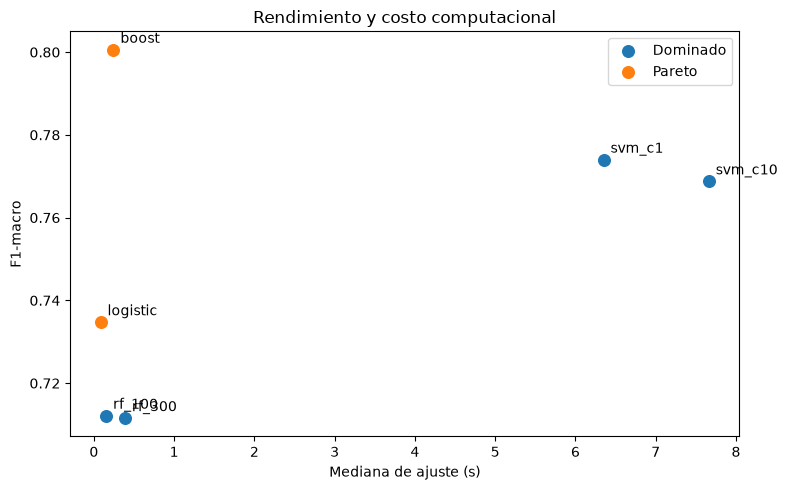

Figura guardada en:
c:\Users\Gladys\INF8239_U01\reports\pareto.png


In [17]:
pareto_path = project_root / "reports" / "pareto.png"

fig, ax = plt.subplots(figsize=(8, 5))

for is_pareto, group in results.groupby("is_pareto"):
    ax.scatter(
        group["fit_median_s"],
        group["f1_macro"],
        label="Pareto" if is_pareto else "Dominado",
        s=70,
    )

for _, row in results.iterrows():
    ax.annotate(
        row["model"],
        (row["fit_median_s"], row["f1_macro"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_xlabel("Mediana de ajuste (s)")
ax.set_ylabel("F1-macro")
ax.set_title("Rendimiento y costo computacional")
ax.legend()

plt.tight_layout()
plt.savefig(
    pareto_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Figura guardada en:")
print(pareto_path)

In [18]:
boost_row = results.loc[results["model"] == "boost"].iloc[0]
logistic_row = results.loc[results["model"] == "logistic"].iloc[0]

f1_difference = (
    boost_row["f1_macro"]
    - logistic_row["f1_macro"]
)

time_saving_pct = (
    (boost_row["fit_median_s"] - logistic_row["fit_median_s"])
    / boost_row["fit_median_s"]
    * 100
)

size_difference_kb = (
    boost_row["size_kb"]
    - logistic_row["size_kb"]
)

size_saving_pct = (
    size_difference_kb
    / boost_row["size_kb"]
    * 100
)

inference_saving_pct = (
    (boost_row["predict_ms"] - logistic_row["predict_ms"])
    / boost_row["predict_ms"]
    * 100
)

print("Diferencia absoluta de F1:", round(f1_difference, 4))
print("Ahorro temporal de logistic vs boost (%):", round(time_saving_pct, 2))
print("Diferencia de tamaño (KB):", round(size_difference_kb, 2))
print("Reducción de tamaño de logistic vs boost (%):", round(size_saving_pct, 2))
print("Ahorro de inferencia de logistic vs boost (%):", round(inference_saving_pct, 2))

Diferencia absoluta de F1: 0.0659
Ahorro temporal de logistic vs boost (%): 65.75
Diferencia de tamaño (KB): 326.8
Reducción de tamaño de logistic vs boost (%): 97.98
Ahorro de inferencia de logistic vs boost (%): 49.09


## Entorno de ejecución

Los tiempos obtenidos dependen del hardware, sistema operativo, versión de Python, versión de scikit-learn y carga del equipo durante la ejecución.

Por tanto, los tiempos se reportan como mediciones contextuales y no como mediciones directas de consumo energético o emisiones de carbono.

In [19]:
import platform
import sys

import sklearn


print("Python:", sys.version)
print("Sistema:", platform.platform())
print("Procesador:", platform.processor())
print("scikit-learn:", sklearn.__version__)

Python: 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
Sistema: Windows-11-10.0.26200-SP0
Procesador: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
scikit-learn: 1.9.1


## Decisión Green AI

La comparación de seis configuraciones mostró diferencias importantes tanto en desempeño predictivo como en costo computacional. El mayor F1-macro fue obtenido por `boost`, con 0.8006, seguido por `svm_c1` con 0.7740. Además, `boost` alcanzó el mayor recall para la clase prioritaria `Revenue=True`, con 0.6126, lo cual resulta relevante debido al desbalance existente en el target y al interés de identificar correctamente las sesiones que finalizan en compra.

La frontera de Pareto estuvo formada únicamente por `boost` y `logistic`. La regresión logística presentó el menor costo computacional, con una mediana de entrenamiento de 0.0837 segundos, frente a 0.2443 segundos para `boost`. Esto representa un ahorro temporal aproximado de 65.75 % a favor de `logistic`. Asimismo, el modelo logístico ocupó aproximadamente 6.74 KB, mientras que `boost` ocupó 333.55 KB, una diferencia de 326.8 KB y una reducción relativa de tamaño de 97.98 % para la regresión logística. En inferencia, `logistic` también fue aproximadamente 49.09 % más rápido.

Sin embargo, este ahorro implica una reducción absoluta de 0.0659 en F1-macro, al pasar de 0.8006 en `boost` a 0.7347 en `logistic`. También se observa una diferencia importante en el recall de `Revenue=True`: 0.6126 para `boost` frente a 0.4136 para `logistic`. Por esta razón, considerando que F1-macro fue definida previamente como la métrica principal y `Revenue=True` como la clase prioritaria, se selecciona `boost` como la alternativa principal del experimento. Su mayor desempeño se obtiene con un tiempo de entrenamiento inferior a un segundo y un tamaño serializado inferior a 1 MB en el entorno evaluado.

Esta decisión no implica que `boost` sea universalmente superior. Los tiempos registrados dependen del hardware, sistema operativo, versiones de software y carga del equipo. Las mediciones se realizaron en Windows 11, Python 3.14.2, scikit-learn 1.9.1 y un procesador Intel64. Los tiempos se interpretan únicamente como indicadores contextuales de costo computacional y no como mediciones directas de consumo energético o emisiones de carbono.